<a href="https://colab.research.google.com/github/vr11-ai/AiModels/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data...
Data loaded!



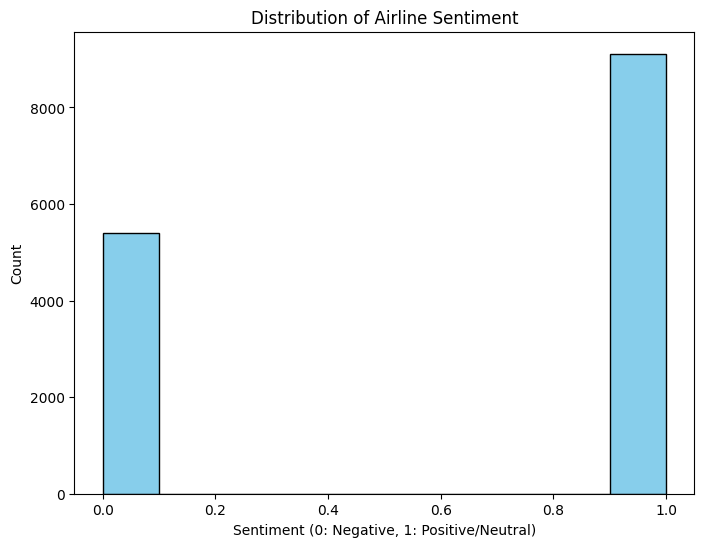

Training model...
Training complete!

--- Model Evaluation ---
Accuracy: 0.82
              precision    recall  f1-score   support

           0       0.80      0.65      0.72      1048
           1       0.82      0.91      0.86      1856

    accuracy                           0.82      2904
   macro avg       0.81      0.78      0.79      2904
weighted avg       0.82      0.82      0.81      2904


--- Interactive Sentiment Analyzer ---
Type 'quit' or 'exit' to stop the program.

Enter a tweet/review: amazing flight
--> Predicted Sentiment: **POSITIVE / NEUTRAL**

Enter a tweet/review: exit
Exiting the analyzer. Goodbye!


/tmp/ipykernel_304/798180149.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


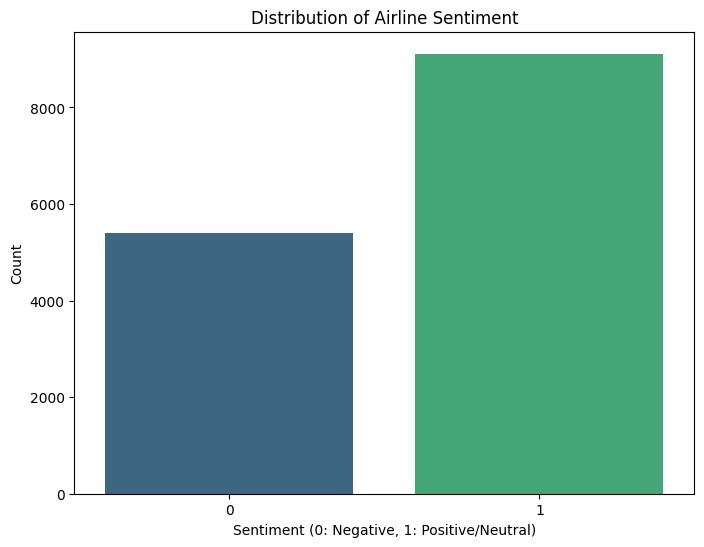

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from google.colab import drive
drive.mount('/content/drive')

print("Loading data...")
df=pd.read_csv('/content/drive/MyDrive/datasets/tweets_preprocessed.csv')
print("Data loaded!\n")

df.dropna(subset=['text_clean', 'airline_sentiment'], inplace=True)

X = df['text_clean']
y = df['airline_sentiment']
plt.figure(figsize=(8, 6))
plt.hist(y,color='skyblue', edgecolor='black')
plt.title('Distribution of Airline Sentiment')
plt.xlabel('Sentiment (0: Negative, 1: Positive/Neutral)')
plt.ylabel('Count')
plt.show()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
model = LogisticRegression(max_iter=1000)

print("Training model...")
X_train_vectorized = vectorizer.fit_transform(X_train)

model.fit(X_train_vectorized, y_train)
print("Training complete!\n")

X_test_vectorized = vectorizer.transform(X_test)
predictions = model.predict(X_test_vectorized)

print("--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")
print(classification_report(y_test, predictions))

def predict_sentiment(text, trained_vectorizer, trained_model):
    """Transforms raw text and predicts its sentiment based on your custom data."""
    text_vectorized = trained_vectorizer.transform([text])
    prediction = trained_model.predict(text_vectorized)[0]

    if prediction == 1:
        return "NEGATIVE"
    else:
        return "POSITIVE / NEUTRAL"

print("\n" + "="*40)
print("--- Interactive Sentiment Analyzer ---")
print("Type 'quit' or 'exit' to stop the program.")
print("="*40)

while True:
    user_input = input("\nEnter a tweet/review: ")

    if user_input.lower() in ['quit', 'exit']:
        print("Exiting the analyzer. Goodbye!")
        break
    if user_input.strip() == "":
        continue

    result = predict_sentiment(user_input, vectorizer, model)
    print(f"--> Predicted Sentiment: **{result}**")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x=y, palette='viridis')
plt.title('Distribution of Airline Sentiment')
plt.xlabel('Sentiment (0: Negative, 1: Positive/Neutral)')
plt.ylabel('Count')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, predictions)

cm_df = pd.DataFrame(cm, index=['Actual Negative', 'Actual Positive/Neutral'], columns=['Predicted Negative', 'Predicted Positive/Neutral'])
display(cm_df)